# RMP2 QChem test: He cc-pv5z, $\theta=0.01$
In this notebook we will analythe the results compared with qchem for He cc-pv5z basis set with RMP2 method and $\theta=0.01$. In particular we will check the implementation using `eig` since the use of `eigh` is not possible for complex matrices.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.MP2.CSMP2 import CS_MP2
from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.external import RHF_context_from_pyscf

We start by setting up the atom with the cc-pV5Z basis set:

In [2]:
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": 'aug-cc-pvqz',
}

mol_He_qz = gto.M(**pyscf_args)

We define this function which will be useful later:

In [3]:
def round_significant_figures(arr, n=4):
    """
    Rounds array to significant figures.
    """
    to_round = (arr != 0)

    logs = np.floor(np.log10(np.abs(arr[to_round])))
    decimals = n - 1 - logs

    rounded = np.zeros_like(arr, dtype=np.float64)
    
    # Apply the scaling factor
    power = 10.0 ** decimals
    
    # Round elements
    rounded_values = np.round(arr[to_round] * power) / power
    rounded[to_round] = rounded_values
    
    return rounded

def round_significant_figures_(x, n):
    '''
    Rounds x to n significant figures. From Greg at https://stackoverflow.com/a/18918700. 
    '''
    return np.round(x, -int(np.floor(np.sign(x) * np.log10(abs(x)))) + n)

The reference value of Qchem for the CSRHF with $\theta=0.01$ is $-2.8615224532 + 0.0000035001i$. The implementation SCF result is calculated as:

In [4]:
CSRHF_reference_energy = -2.8615224532 + 0.0000035001j
He_qz_001 = RHF_context_from_pyscf(**pyscf_args)
He_qz_001.theta = 0.01
He_qz_001.threshold = 1e-8

He_qz_001_res = CS_RHF(He_qz_001)

print(f'CSRHF energy: {He_qz_001_res.E_RHF}')
print(f'Difference with reference: {He_qz_001_res.E_RHF - CSRHF_reference_energy}')

CSRHF energy: (-2.861522453172853+3.5000921216506165e-06j)
Difference with reference: (2.7147173398134328e-11-7.8783493837166e-12j)


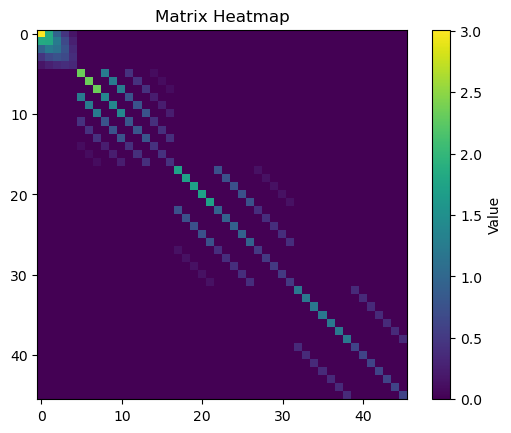

In [5]:
plot_map(He_qz_001_res.context.eri[:,:,0,0])

The CS-RMP2 reference value for this case is $-2.89724685 + 0.00002186i$. Comparing with the implementation:

In [6]:
RMP2_reference_energy = (-2.89724685 + 0.00002186j) # (-2.89724685 , 0.00002186)

He_qz_001_MP2 = CS_MP2(He_qz_001_res)
print(f'CS-RMP2 energy: {He_qz_001_MP2.E_MP2}')
print(f'Difference with reference: {He_qz_001_MP2.E_MP2 - RMP2_reference_energy:.4e}')

CS-RMP2 energy: (-2.897246846886732+2.186466795680325e-05j)
Difference with reference: 3.1133e-09+4.6680e-09j


In [7]:
He_qz_001_res.e_orb

array([-0.91793256+5.67965906e-06j,  0.09871581-2.42252466e-03j,
        0.34776625-6.47500049e-03j,  0.34776625-6.47500049e-03j,
        0.34776625-6.47500049e-03j,  0.68519451-1.69382484e-02j,
        1.14874718-2.24162067e-02j,  1.14874718-2.24162067e-02j,
        1.14874718-2.24162067e-02j,  1.14874718-2.24162067e-02j,
        1.14874718-2.24162067e-02j,  1.47579723-2.86019427e-02j,
        1.47579723-2.86019427e-02j,  1.47579723-2.86019427e-02j,
        2.95497077-6.80835930e-02j,  3.00262996-5.91382123e-02j,
        3.00262996-5.91382123e-02j,  3.00262996-5.91382123e-02j,
        3.00262996-5.91382123e-02j,  3.00262996-5.91382123e-02j,
        3.00262996-5.91382123e-02j,  3.00262996-5.91382123e-02j,
        4.57642802-8.96266210e-02j,  4.57642802-8.96266210e-02j,
        4.57642802-8.96266210e-02j,  4.57642802-8.96266210e-02j,
        4.57642802-8.96266210e-02j,  5.1292926 -1.02849213e-01j,
        5.1292926 -1.02849213e-01j,  5.1292926 -1.02849213e-01j,
       12.53328377-2.4804

And with the rounded orbital energies (since we only have 4 significant figures from qchem):

In [8]:
orig_eorb = np.copy(He_qz_001_res.e_orb)
eorb_round_real = round_significant_figures(He_qz_001_res.e_orb.real, n=4)
eorb_round_imag = round_significant_figures(He_qz_001_res.e_orb.imag, n=4)

eorb_round = eorb_round_real + 1j * eorb_round_imag

He_qz_001_res.e_orb = eorb_round

He_qz_001_MP2_round= CS_MP2(He_qz_001_res)
print(f'CS-RMP2 energy: {He_qz_001_MP2.E_MP2}')
print(f'Difference with reference: {He_qz_001_MP2.E_MP2 - RMP2_reference_energy:.4e}')

He_qz_001_res.e_orb = orig_eorb

CS-RMP2 energy: (-2.897246846886732+2.186466795680325e-05j)
Difference with reference: 3.1133e-09+4.6680e-09j


Which shows a up to significative figure error in the MP2 energy. 

## Locating the cause
The first idea is the same as always: Virtuals are not well defined, inducing error. Since we are limited at this moment by the results of Qchem, we can see what we can compare: orbital energies. 

In [9]:
qchem_eorb_str = '''
    (-9.179e-01,+5.680e-06)
    (+9.872e-02,-2.423e-03)
    (+3.478e-01,-6.475e-03)
    (+3.478e-01,-6.475e-03)
    (+3.478e-01,-6.475e-03)
    (+6.852e-01,-1.694e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.476e+00,-2.860e-02)
    (+1.476e+00,-2.860e-02)
    (+1.476e+00,-2.860e-02)
    (+2.955e+00,-6.808e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+5.129e+00,-1.028e-01)
    (+5.129e+00,-1.028e-01)
    (+5.129e+00,-1.028e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.362e+01,-3.208e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.809e+01,-3.723e-01)
    (+1.809e+01,-3.723e-01)
    (+1.809e+01,-3.723e-01)
'''

qchem_eorb_list = qchem_eorb_str.split('\n')[1:-1]
qchem_eorb_list = [e.strip().replace('(', '').replace(')', '') for e in qchem_eorb_list]

qchem_eorb_re = [float(a.split(',')[0] )for a in qchem_eorb_list]
qchem_eorb_im = [float(a.split(',')[1] )for a in qchem_eorb_list]

qchem_eorb_arr = np.array(qchem_eorb_re) + 1j * np.array(qchem_eorb_im)

In [10]:
print(He_qz_001_res.e_orb )

[-0.91793256+5.67965906e-06j  0.09871581-2.42252466e-03j
  0.34776625-6.47500049e-03j  0.34776625-6.47500049e-03j
  0.34776625-6.47500049e-03j  0.68519451-1.69382484e-02j
  1.14874718-2.24162067e-02j  1.14874718-2.24162067e-02j
  1.14874718-2.24162067e-02j  1.14874718-2.24162067e-02j
  1.14874718-2.24162067e-02j  1.47579723-2.86019427e-02j
  1.47579723-2.86019427e-02j  1.47579723-2.86019427e-02j
  2.95497077-6.80835930e-02j  3.00262996-5.91382123e-02j
  3.00262996-5.91382123e-02j  3.00262996-5.91382123e-02j
  3.00262996-5.91382123e-02j  3.00262996-5.91382123e-02j
  3.00262996-5.91382123e-02j  3.00262996-5.91382123e-02j
  4.57642802-8.96266210e-02j  4.57642802-8.96266210e-02j
  4.57642802-8.96266210e-02j  4.57642802-8.96266210e-02j
  4.57642802-8.96266210e-02j  5.1292926 -1.02849213e-01j
  5.1292926 -1.02849213e-01j  5.1292926 -1.02849213e-01j
 12.53328377-2.48042814e-01j 12.53328377-2.48042814e-01j
 12.53328377-2.48042814e-01j 12.53328377-2.48042814e-01j
 12.53328377-2.48042814e-01j 12

Comparing the difference from implementation and qchem energies:

In [11]:
diff = He_qz_001_res.e_orb - qchem_eorb_arr

eorb_round_real = round_significant_figures(He_qz_001_res.e_orb.real, n=4)
eorb_round_imag = round_significant_figures(He_qz_001_res.e_orb.imag, n=4)

eorb_round = eorb_round_real + 1j * eorb_round_imag

diff_round = eorb_round - qchem_eorb_arr


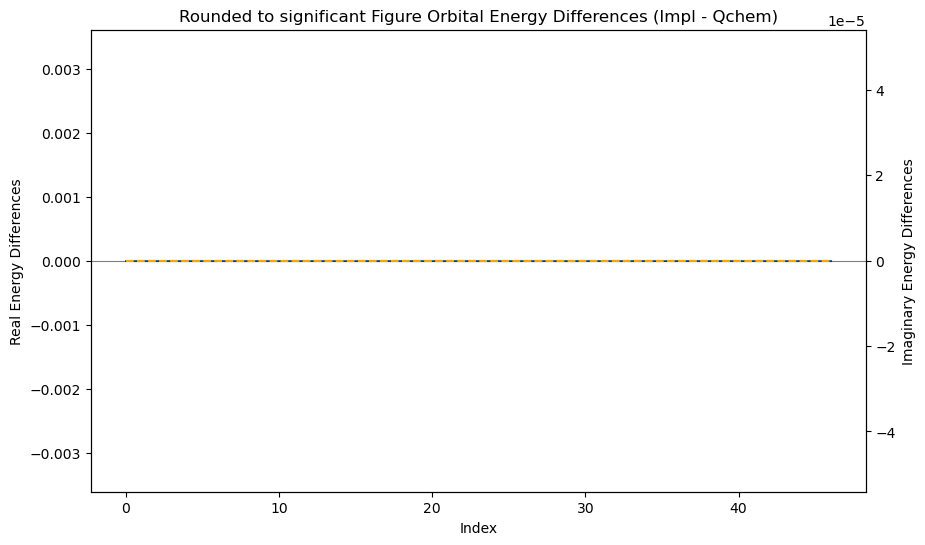

In [12]:
x_range = np.linspace(0, len(diff), len(diff))

fig, ax1 = plt.subplots(figsize=(10, 6))

# real
ax1.set_xlabel('Index')
ax1.set_ylabel('Real Energy Differences')
ax1.plot(x_range, diff_round.real, label='Real')
ax1.tick_params(axis='y')

# imag
ax2 = ax1.twinx()
ax2.set_ylabel('Imaginary Energy Differences')
ax2.plot(x_range, diff_round.imag, linestyle='--', label='Imag', c='orange')
ax2.tick_params(axis='y')

#scale
max_real = np.max(np.abs(diff.real))
max_imag = np.max(np.abs(diff.imag))
limit_real = max_real * 1.1
limit_imag = max_imag * 1.1

ax1.set_ylim(-limit_real, limit_real)
ax2.set_ylim(-limit_imag, limit_imag)

ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.title("Rounded to significant Figure Orbital Energy Differences (Impl - Qchem)")
plt.show()

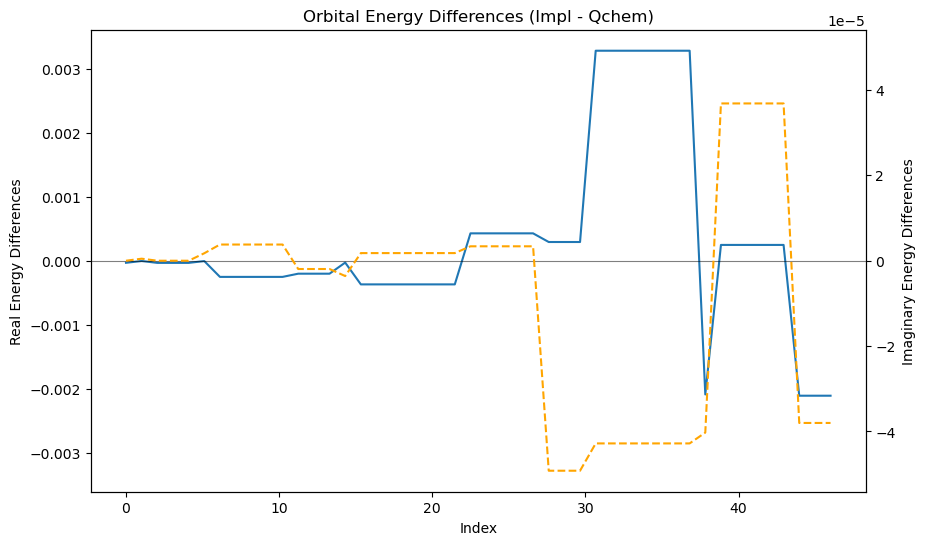

In [13]:
x_range = np.linspace(0, len(diff), len(diff))

fig, ax1 = plt.subplots(figsize=(10, 6))

# real
ax1.set_xlabel('Index')
ax1.set_ylabel('Real Energy Differences')
ax1.plot(x_range, diff.real, label='Real')
ax1.tick_params(axis='y')

# imag
ax2 = ax1.twinx()
ax2.set_ylabel('Imaginary Energy Differences')
ax2.plot(x_range, diff.imag, linestyle='--', label='Imag', c='orange')
ax2.tick_params(axis='y')

#scale
max_real = np.max(np.abs(diff.real))
max_imag = np.max(np.abs(diff.imag))
limit_real = max_real * 1.1
limit_imag = max_imag * 1.1

ax1.set_ylim(-limit_real, limit_real)
ax2.set_ylim(-limit_imag, limit_imag)

ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.title("Orbital Energy Differences (Impl - Qchem)")
plt.show()